In [2]:
###############################################################################
# CHAPTER 1: FORECASTING PRINCIPLES & PRACTICE — PYTHON (COMPLETE SCRIPT)
###############################################################################

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
import sys
!{sys.executable} -m pip install numpy pandas matplotlib seaborn statsforecast utilsforecast fpppy ipywidgets openpyxl
!{sys.executable} -m pip install statsforecast --only-binary=:all:



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 3.2 MB/s  0:00:06m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 20.0 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:0m━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  2/16 [scipy]
      Successfully uninstalled scipy-1.16.3━━━━━━━━━━━━━━━━━━━  2/16 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [statsforecast]0m [fugue]mmit]


In [3]:

# =========================
# 1. GLOBAL SETTINGS
# =========================
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)

import os
os.environ["NIXTLA_ID_AS_COL"] = "true"

import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)

import random
random.seed(1)

import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)

# =========================
# 2. PLOTTING STYLE (FPP)
# =========================

import statsmodels.api as sm

import seaborn as sns
sns.set_style("whitegrid")

import matplotlib.pyplot as plt
plt.style.use("ggplot")

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
})

import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#2f2fff"])


In [14]:

# =========================
# 3. LIBRARY IMPORTS
# =========================
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from utilsforecast.plotting import plot_series
from pathlib import Path


/Applications/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:378: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/Applications/anaconda3/lib/python3.13/site-packages/utilsforecast/processing.py:434: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  freq = pd.tseries.frequencies.to_offset(freq)
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_11278/3632601266.py:75: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


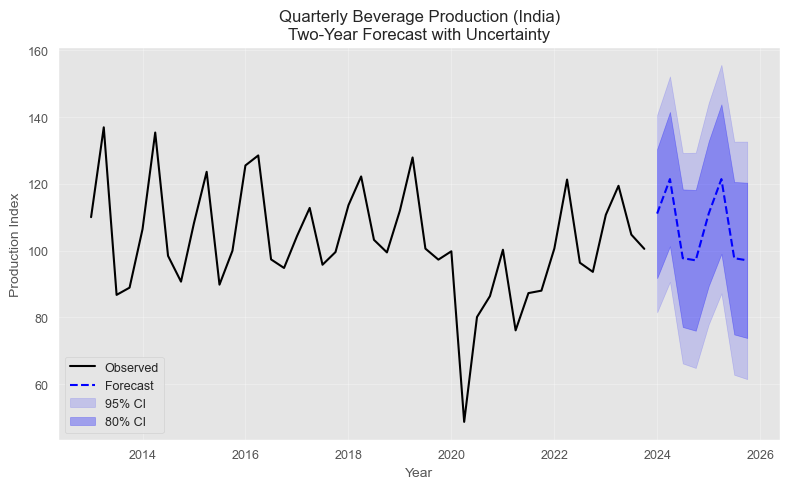

In [20]:
# =========================
# FIGURE 1.1: QUARTERLY BEVERAGE PRODUCTION (ETS)
# =========================

data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")
file_path = data_dir / "india_quart_bevg_prod_index_2013_2023.xlsx"


df_q = pd.read_excel(file_path, engine="openpyxl")

df_q.columns = df_q.columns.str.strip().str.lower()
df_q['ds'] = pd.to_datetime(df_q['ds'])
df_q = df_q.rename(columns={'beverage_prod_index': 'y'})
df_q['unique_id'] = 'Beverage Production'
df_q = df_q[['unique_id', 'ds', 'y']]

sf_q = StatsForecast(
    models=[AutoETS(season_length=4)],
    freq='Q',
    n_jobs=1
)

sf_q = sf_q.fit(df_q)

# --- Forecast with confidence intervals ---
fcst_q = sf_q.predict(h=8, level=[80, 95])

# --- Plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# Observed series
ax.plot(
    df_q['ds'],
    df_q['y'],
    color='black',
    label='Observed'
)

# Point forecast
ax.plot(
    fcst_q['ds'],
    fcst_q['AutoETS'],
    color='blue',
    linestyle='--',
    label='Forecast'
)

# 95% confidence interval
ax.fill_between(
    fcst_q['ds'],
    fcst_q['AutoETS-lo-95'],
    fcst_q['AutoETS-hi-95'],
    color='blue',
    alpha=0.15,
    label='95% CI'
)

# 80% confidence interval
ax.fill_between(
    fcst_q['ds'],
    fcst_q['AutoETS-lo-80'],
    fcst_q['AutoETS-hi-80'],
    color='blue',
    alpha=0.30,
    label='80% CI'
)

ax.set_title("Quarterly Beverage Production (India)\nTwo-Year Forecast with Uncertainty")
ax.set_xlabel("Year")
ax.set_ylabel("Production Index")
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(fig_dir / "fig_01_01.png", dpi=300, bbox_inches="tight")

plt.show()
plt.close(fig)
 

/Applications/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_11278/117261485.py:30: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  future_years = pd.date_range(
/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_11278/117261485.py:62: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


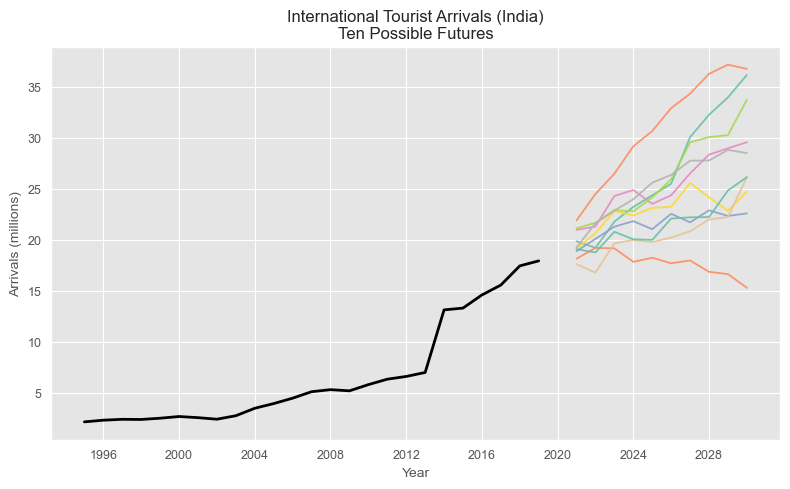

In [22]:
# =========================
# FIGURE 1.2: TEN POSSIBLE FUTURES (ARIMA)
# =========================

data_dir = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/data")
fig_dir  = Path("/Users/satyendragupta/Library/CloudStorage/OneDrive-econdse.org/Documents/_Teaching/Forecasting/figures")
file_path = data_dir / "india_yearly_intl_tourist_arrivals_1995_2019.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

df.columns = df.columns.str.strip().str.lower()

# create time series (IN MILLIONS)
y = pd.Series(
    df['intl_tourist_arrivals'].values / 1_000_000,   # 🔑 SCALE FIRST
    index=pd.to_datetime(df['year'], format="%Y")
).asfreq('YS')

res = sm.tsa.ARIMA(y, order=(1,1,1)).fit()

h = 10
n_sims = 10

simulations = res.simulate(
    nsimulations=h,
    repetitions=n_sims,
    anchor='end'
).to_numpy()

future_years = pd.date_range(
    y.index[-1] + pd.DateOffset(years=1),
    periods=h,
    freq='Y'
)

plt.figure(figsize=(8, 5))

# observed series
plt.plot(
    y.index,
    y.values,
    color='black',
    linewidth=2,
    label='Observed'
)

# muted colour palette (like book)
colors = plt.cm.Set2.colors

for i in range(n_sims):
    plt.plot(
        future_years,
        simulations[:, i],
        color=colors[i % len(colors)],
        linewidth=1.3,
        alpha=0.9
    )

plt.title("International Tourist Arrivals (India)\nTen Possible Futures")
plt.xlabel("Year")
plt.ylabel("Arrivals (millions)")
plt.tight_layout()
plt.savefig(fig_dir / "fig_01_02.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/2h/y81mf9fj7vn3ly3y3t73z9140000gn/T/ipykernel_11278/291552034.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


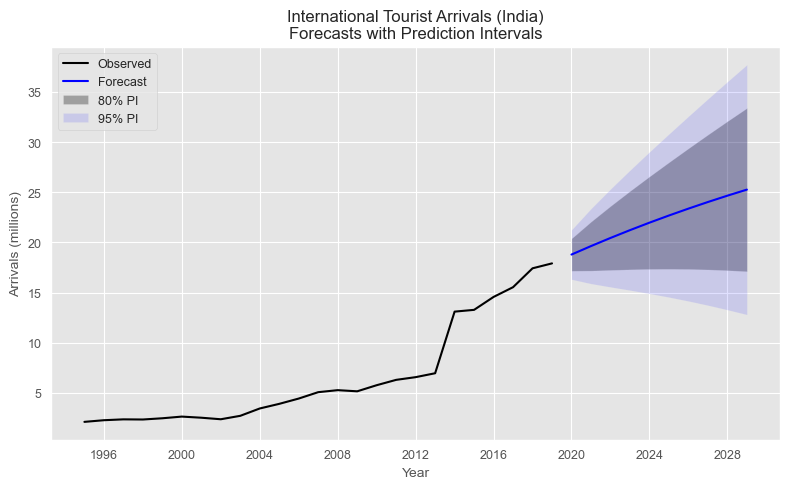

In [24]:
# =========================
# FIGURE 1.3: PREDICTION INTERVALS (ARIMA)
# =========================

fcst = res.get_forecast(h)
mean = fcst.predicted_mean
ci80 = fcst.conf_int(alpha=0.20)
ci95 = fcst.conf_int(alpha=0.05)

plt.figure(figsize=(8, 5))
plt.plot(y, color='black', label='Observed')
plt.plot(mean, color='blue', label='Forecast')
plt.fill_between(mean.index, ci80.iloc[:, 0], ci80.iloc[:, 1], alpha=0.30, label='80% PI')
plt.fill_between(mean.index, ci95.iloc[:, 0], ci95.iloc[:, 1], alpha=0.15, label='95% PI')
plt.title("International Tourist Arrivals (India)\nForecasts with Prediction Intervals")
plt.xlabel("Year")
plt.ylabel("Arrivals (millions)")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "fig_01_03.png", dpi=300, bbox_inches="tight")
plt.show()
